In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Read data
df=pd.read_csv('amazon_data_stores.csv')
df.head(5)

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,...,product_id,category,sub-category,product_name,sales,quantity,profit,returns,payment_mode,profit_margin
0,CA-2019-160304,01-01-2019,01-07-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,...,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",84.982150,1.0,27.198653,0,Online,0.3823
1,CA-2019-160304,01-02-2019,01-07-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,...,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",166.877557,3.0,35.144083,0,Online,0.2200
2,CA-2019-160304,01-02-2019,01-07-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,...,TEC-PH-10000455,Technology,Phones,GE 30522EE2,236.355222,2.0,62.094535,0,Cards,0.2900
3,CA-2019-125206,01-03-2019,01-05-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,...,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,122.691776,2.0,25.805250,0,Online,0.2500
4,US-2019-116365,01-03-2019,01-08-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,...,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,28.016566,2.0,-5.929247,1,Online,-0.1750


## STEP 2. DATA PRE_PROCESSING AND TARGET VARIABLES

In [3]:
# Target variables
df['profit'] = pd.qcut(df['profit'], q=2, labels=[0,1]).astype(int)

In [4]:
# shape in our dataset
df.shape

(5901, 21)

In [5]:
# statistical analysis in our dataset
df.describe()

,sales,quantity,profit,returns,profit_margin
count,5901.000000,5901.000000,5901.000000,5901.000000,5901.000000
mean,189.672856,3.750297,0.499915,0.498221,0.098722
std,172.749275,2.105675,0.500042,0.500039,0.273427
min,0.851047,1.000000,0.000000,0.000000,-2.700000
25%,71.432070,2.000000,0.000000,0.000000,0.018600
50%,127.971883,3.000000,0.000000,0.000000,0.100000
75%,265.589702,5.000000,1.000000,1.000000,0.260000
max,719.405960,9.500000,1.000000,1.000000,1.346200


In [6]:
# Checking type of columns present in our dataset: 
df.dtypes 

order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
region            object
product_id        object
category          object
sub-category      object
product_name      object
sales            float64
quantity         float64
profit             int32
returns            int64
payment_mode      object
profit_margin    float64
dtype: object

In [7]:
# Checking number of rows and columns present in the dataset: 
df.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       5901 non-null   object 
 1   order_date     5901 non-null   object 
 2   ship_date      5901 non-null   object 
 3   ship_mode      5901 non-null   object 
 4   customer_id    5901 non-null   object 
 5   customer_name  5901 non-null   object 
 6   segment        5901 non-null   object 
 7   country        5901 non-null   object 
 8   city           5901 non-null   object 
 9   state          5901 non-null   object 
 10  region         5901 non-null   object 
 11  product_id     5901 non-null   object 
 12  category       5901 non-null   object 
 13  sub-category   5901 non-null   object 
 14  product_name   5901 non-null   object 
 15  sales          5901 non-null   float64
 16  quantity       5901 non-null   float64
 17  profit         5901 non-null   int32  
 18  returns 

In [8]:
df= df.drop_duplicates()
print("/n duplicate rows:",df.duplicated().sum())

/n duplicate rows: 0


## STEP 3. HANDLING MISSING COLUMNS

In [9]:
# Fill missing values in specific columns
df['category'] = df['category'].fillna(df['category'].mode()[0])          # Fill with most common route
df['returns'] = df['returns'].fillna(df['returns'].mode()[0])  # Fill with most common stop count

In [10]:
# check any null values present in the dataset:
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
profit           0
returns          0
payment_mode     0
profit_margin    0
dtype: int64

In [11]:
print("\n--- First 5 rows of the dataset ---")
print(df.head())


--- First 5 rows of the dataset ---
         order_id  order_date   ship_date       ship_mode customer_id  \
0  CA-2019-160304  01-01-2019  01-07-2019  Standard Class    BM-11575   
1  CA-2019-160304  01-02-2019  01-07-2019  Standard Class    BM-11575   
2  CA-2019-160304  01-02-2019  01-07-2019  Standard Class    BM-11575   
3  CA-2019-125206  01-03-2019  01-05-2019     First Class    LR-16915   
4  US-2019-116365  01-03-2019  01-08-2019  Standard Class    CA-12310   

       customer_name    segment        country          city       state  ...  \
0      Brendan Murry  Corporate  United States  Gaithersburg    Maryland  ...   
1      Brendan Murry  Corporate  United States  Gaithersburg    Maryland  ...   
2      Brendan Murry  Corporate  United States  Gaithersburg    Maryland  ...   
3       Lena Radford   Consumer  United States   Los Angeles  California  ...   
4  Christine Abelman  Corporate  United States   San Antonio       Texas  ...   

        product_id         category s

## STEP 4. VISUALIZATION THE DATA BY CHARTS

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#--- 4. Visualization (EDA) ---

# Set a consistent style for the plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12




Generated 'payment_mode_distribution.png'


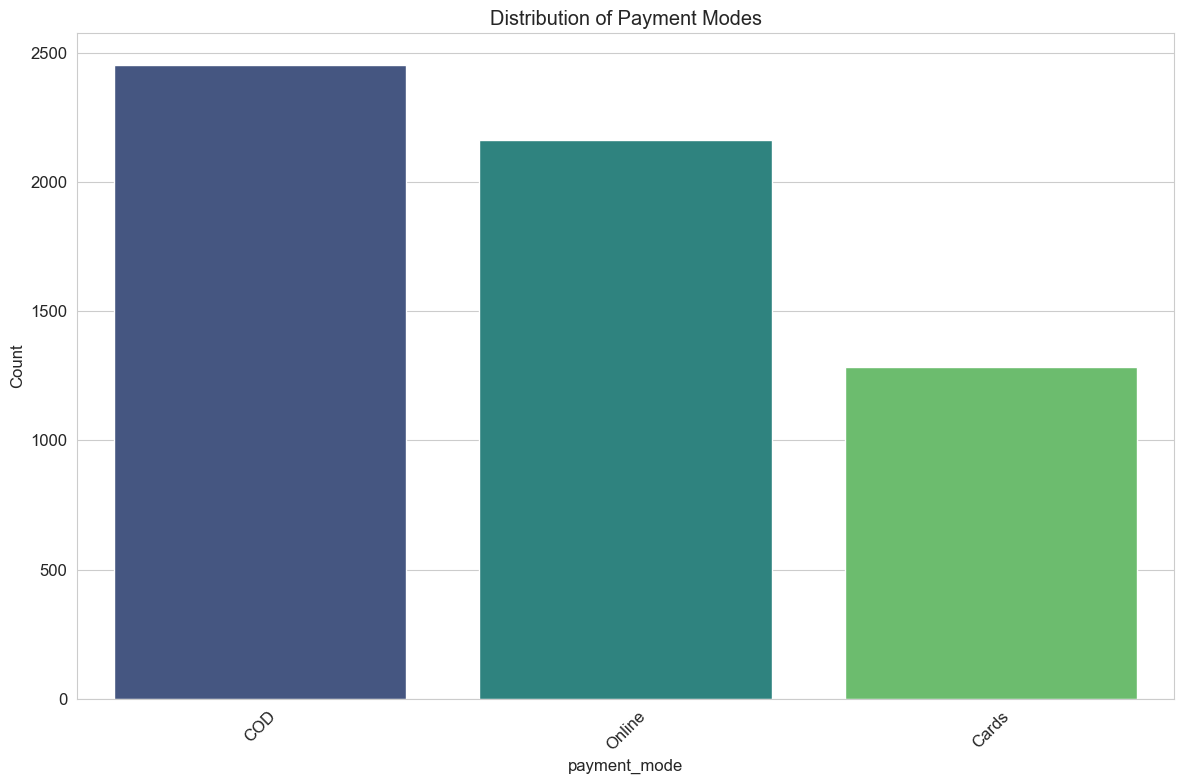

In [13]:
# Plot 1: Bar chart for Payment Mode distribution
plt.figure()
payment_mode_counts = df['payment_mode'].value_counts()
sns.barplot(x=payment_mode_counts.index, y=payment_mode_counts.values, palette='viridis')
plt.title('Distribution of Payment Modes')
plt.xlabel('payment_mode')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('payment_mode_distribution.png')
print("\nGenerated 'payment_mode_distribution.png'")


Generated 'sales_by_category.png'


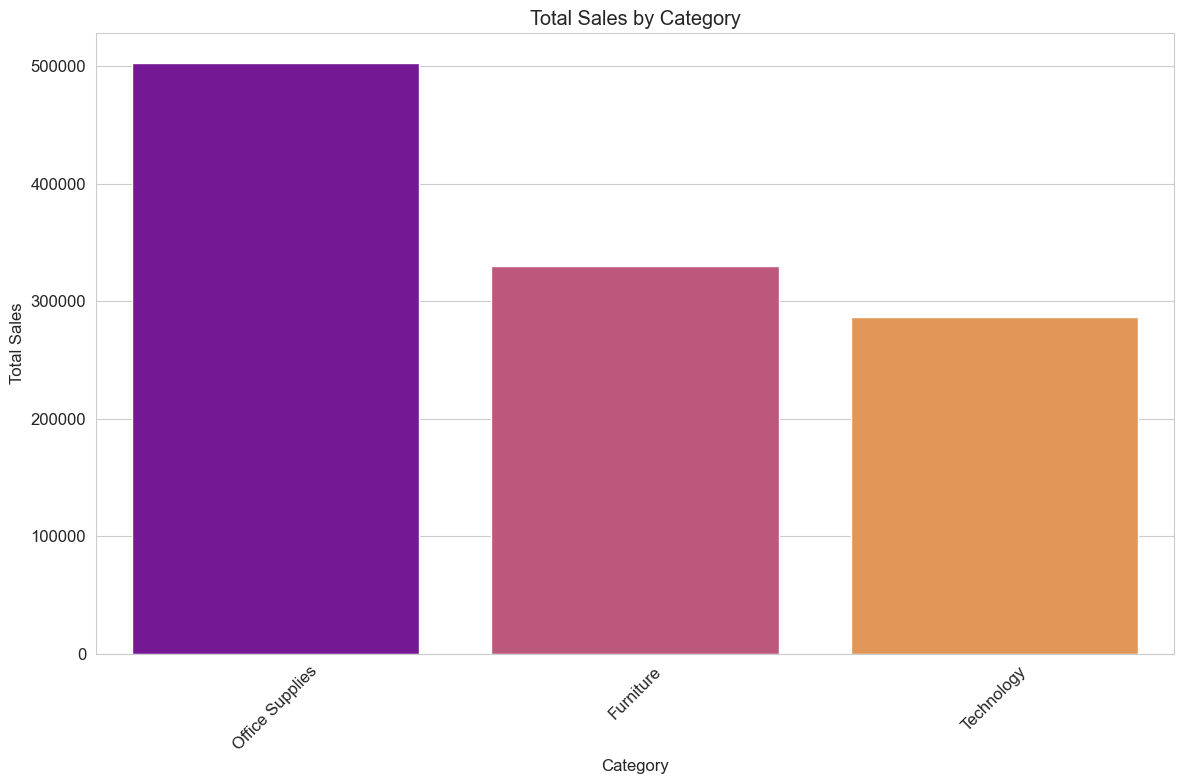

In [14]:
# Plot 2: Bar chart for Sales by Category
plt.figure()
sales_by_category = df.groupby('category')['sales'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette='plasma')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_category.png')
print("Generated 'sales_by_category.png'")

Generated 'sales_distribution.png'


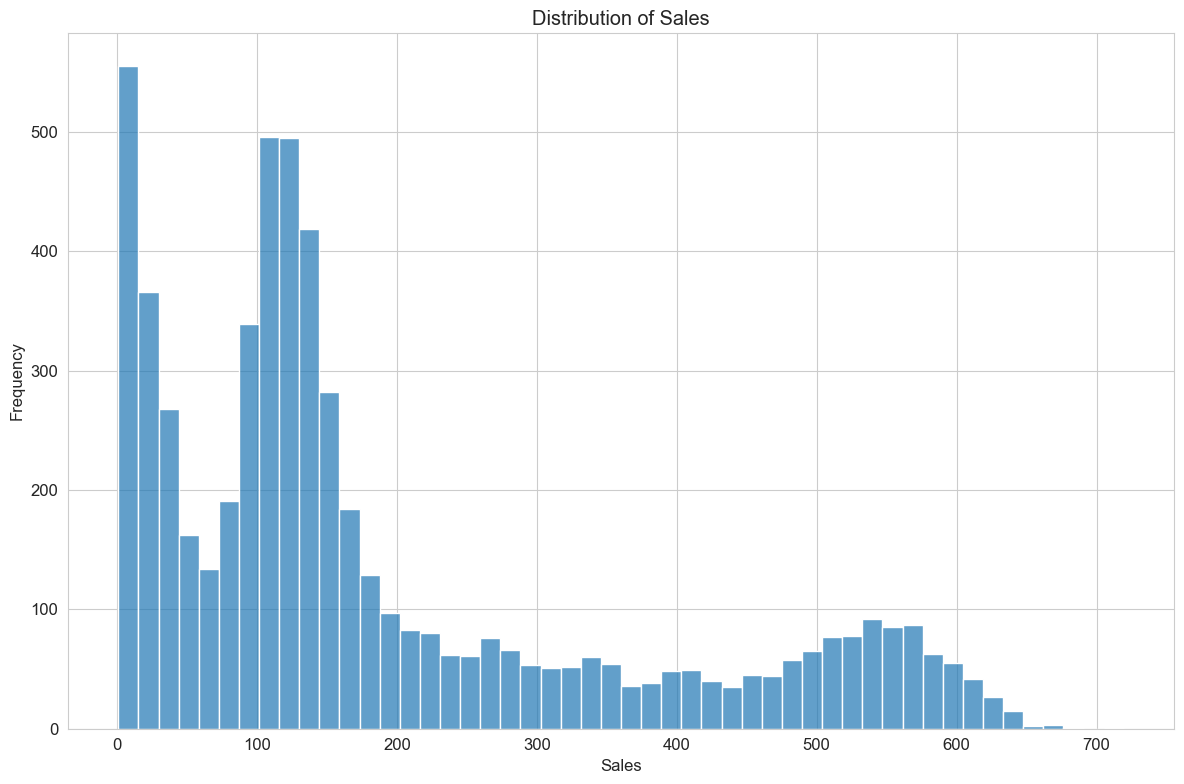

In [15]:
# Plot 3: Histogram for Sales distribution
plt.figure()
# Using a log scale can help visualize skewed data more clearly.
sns.histplot(df['sales'], bins=50, alpha=0.7)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('sales_distribution.png')
print("Generated 'sales_distribution.png'")


In [16]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id',
       'customer_name', 'segment', 'country', 'city', 'state', 'region',
       'product_id', 'category', 'sub-category', 'product_name', 'sales',
       'quantity', 'profit', 'returns', 'payment_mode', 'profit_margin'],
      dtype='object')

In [17]:
df['profit'].value_counts()

profit
0    2951
1    2950
Name: count, dtype: int64

<BarContainer object of 3 artists>

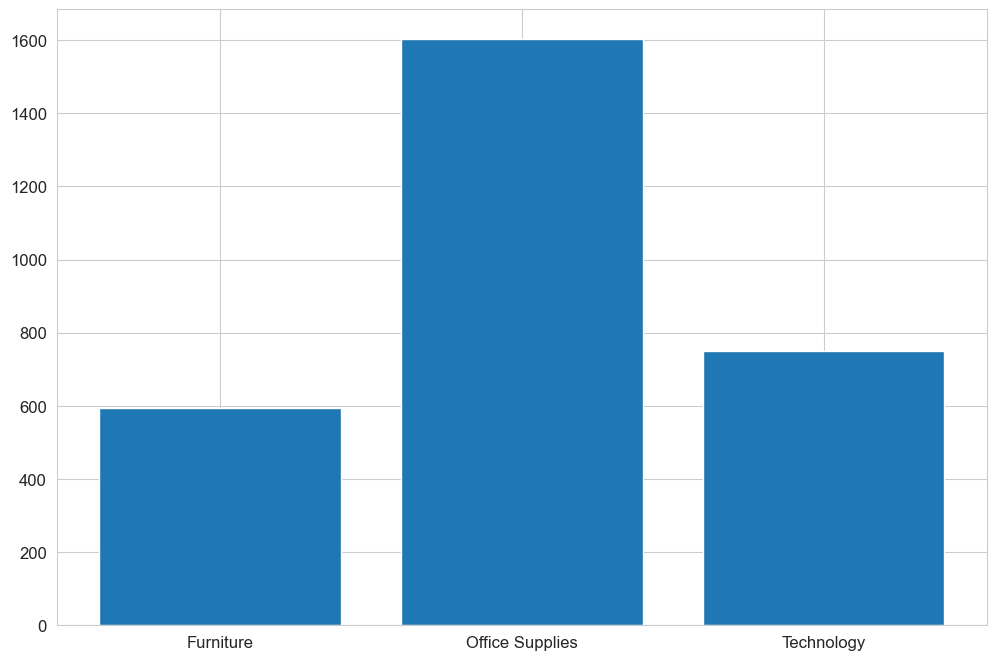

In [18]:
# Plot 5: Bar Chart for Returns by Category
profit_by_category = df.groupby('category')['profit'].sum()
plt.savefig('profit_by_category.png')
plt.bar(profit_by_category.index, profit_by_category.values)



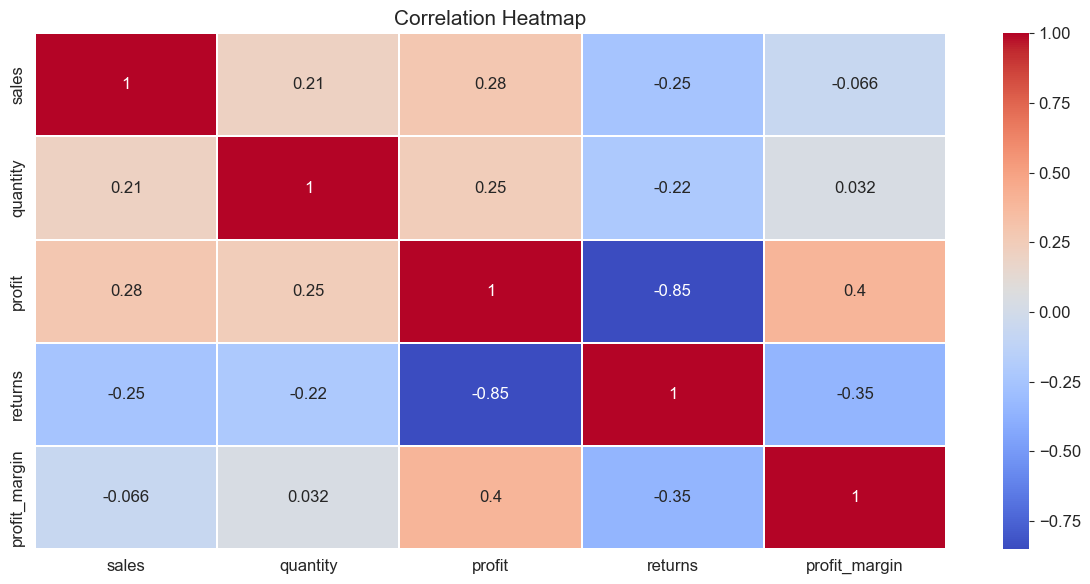

<Figure size 1200x800 with 0 Axes>

In [19]:
# 5️. Correlation Heatmap 
#correlation between numeric variables in the dataset using a color-coded heatmap to reveal strong positive or negative relationships.
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', linewidths=0.3,annot=True)
plt.title('Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()
plt.savefig('correlation_Heatmap.png')

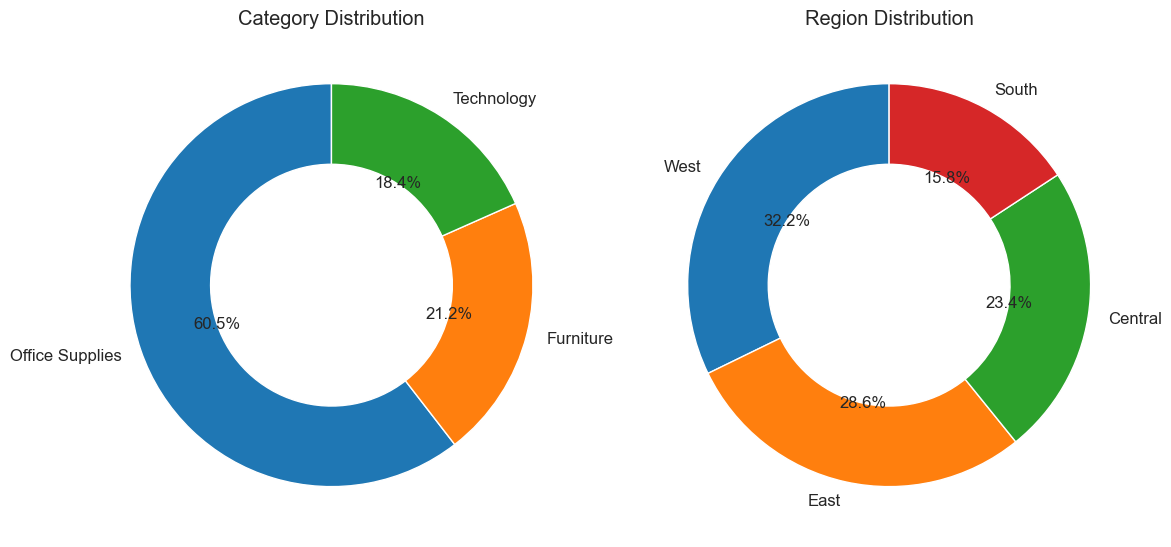

In [20]:
# Count the values for Category and Region
category_counts = df['category'].value_counts()
region_counts = df['region'].value_counts()

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Donut Chart 1 - Category
axes[0].pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)
axes[0].set_title("Category Distribution")

# Donut Chart 2 - Region
axes[1].pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)
axes[1].set_title("Region Distribution")
plt.savefig('category and region_distribution.png')

# Equal aspect ratio ensures pie is drawn as a circle
plt.tight_layout()
plt.show()

## STEP 5. DATA SPLITING

In [21]:
# Step 4: Split and Standardize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encode 
df = pd.get_dummies(df, drop_first=True)

# Train-Test Split
# training (80%) and testing (20%)
X = df.drop(columns=['profit'])
y = df['profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (4720, 9903)
Test shape: (1181, 9903)


## STEP 6. MODEL TRAINING

In [22]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [23]:
# Train model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train_scaled, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# Prediction
rf_pred = rf.predict(X_test_scaled)

In [25]:
# Evaluation
print("🔹 Random Forest Results")
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, rf_pred)))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

🔹 Random Forest Results
Accuracy: 0.93%

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       591
           1       0.93      0.92      0.93       590

    accuracy                           0.93      1181
   macro avg       0.93      0.93      0.93      1181
weighted avg       0.93      0.93      0.93      1181



In [31]:
# XGBoost Model.
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [32]:
# Model Training using XGBoost
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [33]:
# Predictions
xgb_pred = xgb.predict(X_test_scaled)

In [34]:
# Evaluation
print("🔹 XGBoost Results")
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, xgb_pred)))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))

🔹 XGBoost Results
Accuracy: 0.97%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       591
           1       0.98      0.97      0.97       590

    accuracy                           0.97      1181
   macro avg       0.97      0.97      0.97      1181
weighted avg       0.97      0.97      0.97      1181



## SUMMARY OF THE PROJECT

## This project uses machine learning to predict profit based on Amazon sales data . A Random Forest classifier was trained on the processed data to learn relationships between profit and sales. And aslo displaying the VISUALIZATION CHARTS. The model achieved around 93% accuracy, indicating good predictive performance without overfitting. This approach ensures reliable and practical results suitable for real-world applications. Overall, the project demonstrates how proper data preprocessing, feature handling, and model selection was Done.

Generated 'sales_distribution.png'


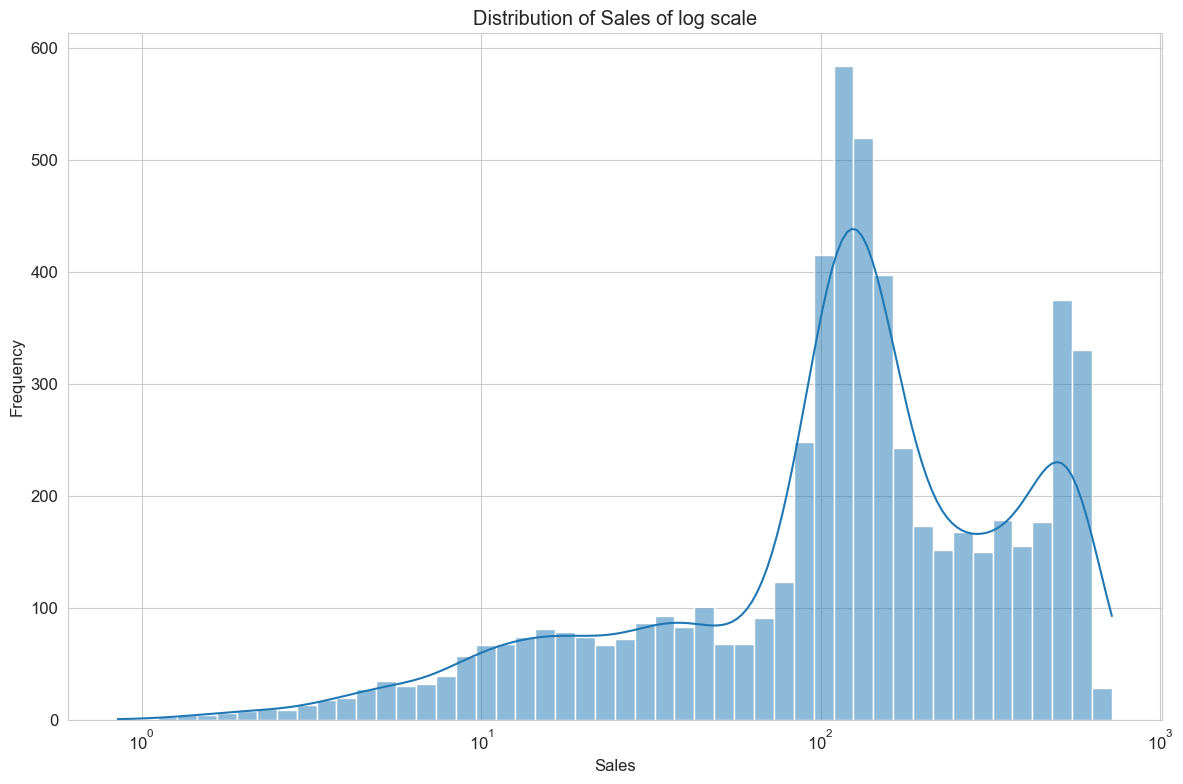

In [35]:
plt.figure()
# Using a log scale can help visualize skewed data more clearly.
sns.histplot(df['sales'], bins=50, log_scale=True, kde=True)
plt.title('Distribution of Sales of log scale')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('sales_distribution.png')
print("Generated 'sales_distribution.png'")
